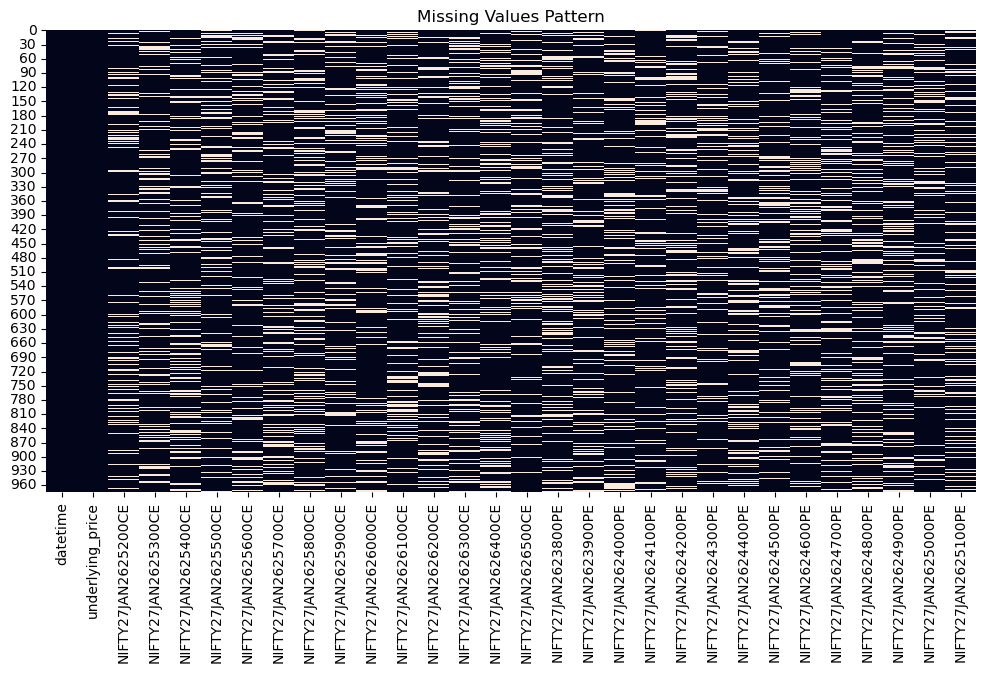

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset.csv")

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Pattern")
plt.show()

In [4]:
df.isnull().sum().sort_values(ascending=False)

NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2624000PE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2626200CE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
NIFTY27JAN2625700CE    201
NIFTY27JAN2623900PE    201
NIFTY27JAN2624600PE    198
NIFTY27JAN2624900PE    195
NIFTY27JAN2624500PE    195
NIFTY27JAN2625000PE    195
NIFTY27JAN2625200CE    194
NIFTY27JAN2624300PE    189
NIFTY27JAN2626300CE    187
NIFTY27JAN2626500CE    184
NIFTY27JAN2625300CE    184
NIFTY27JAN2626100CE    183
NIFTY27JAN2625900CE    182
NIFTY27JAN2626000CE    181
NIFTY27JAN2625500CE    181
NIFTY27JAN2625600CE    180
NIFTY27JAN2624100PE    176
NIFTY27JAN2624700PE    175
underlying_price         0
datetime                 0
dtype: int64

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print(missing.sort_values(ascending=False))

NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2626200CE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2624000PE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
NIFTY27JAN2625700CE    201
NIFTY27JAN2623900PE    201
NIFTY27JAN2624600PE    198
NIFTY27JAN2625000PE    195
NIFTY27JAN2624900PE    195
NIFTY27JAN2624500PE    195
NIFTY27JAN2625200CE    194
NIFTY27JAN2624300PE    189
NIFTY27JAN2626300CE    187
NIFTY27JAN2626500CE    184
NIFTY27JAN2625300CE    184
NIFTY27JAN2626100CE    183
NIFTY27JAN2625900CE    182
NIFTY27JAN2626000CE    181
NIFTY27JAN2625500CE    181
NIFTY27JAN2625600CE    180
NIFTY27JAN2624100PE    176
NIFTY27JAN2624700PE    175
dtype: int64


In [6]:
print("\nTotal Missing Values:", df.isnull().sum().sum())


Total Missing Values: 5460


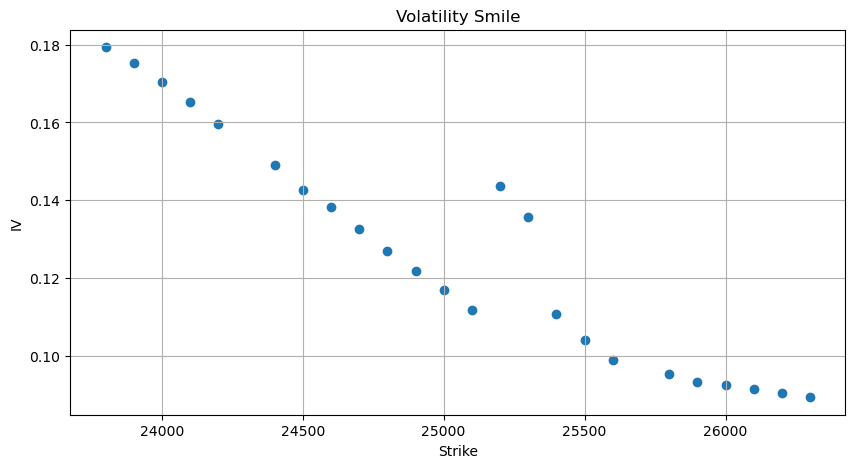

In [7]:
import matplotlib.pyplot as plt

row = 100  # choose any row

option_cols = [c for c in df.columns
               if c not in ['datetime','underlying_price']]

strikes = []

for col in option_cols:
    strike = int(col[-7:-2])   # extracts 25200 from NIFTY27JAN2625200CE
    strikes.append(strike)

ivs = df.loc[row, option_cols]

plt.figure(figsize=(10,5))
plt.scatter(strikes, ivs)
plt.xlabel("Strike")
plt.ylabel("IV")
plt.title("Volatility Smile")
plt.grid()
plt.show()

In [8]:
print(df['underlying_price'].describe())

count      975.000000
mean     25564.155846
std        317.642518
min      24940.700000
25%      25266.850000
50%      25624.200000
75%      25768.200000
max      26183.800000
Name: underlying_price, dtype: float64


In [9]:
import pandas as pd

df = pd.read_csv("dataset.csv")

filled = df.copy()

option_cols = [c for c in df.columns
               if c not in ['datetime','underlying_price']]

filled[option_cols] = filled[option_cols].interpolate(
    axis=1,
    limit_direction='both'
)

filled[option_cols] = filled[option_cols].ffill().bfill()

print(filled.isnull().sum().sum())

0


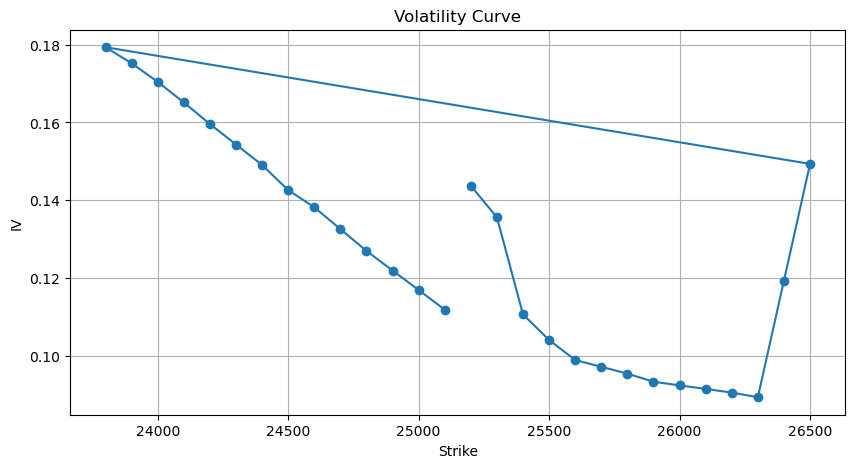

In [10]:
import matplotlib.pyplot as plt

row = 100

ivs = filled.loc[row, option_cols]

strikes = []

for col in option_cols:
    strike = int(col[-7:-2])
    strikes.append(strike)

plt.figure(figsize=(10,5))
plt.plot(strikes, ivs, marker='o')
plt.xlabel("Strike")
plt.ylabel("IV")
plt.title("Volatility Curve")
plt.grid()
plt.show()

In [11]:
import pandas as pd

df = pd.read_csv("dataset.csv")

option_cols = [c for c in df.columns
               if c not in ['datetime','underlying_price']]

long_df = df.melt(
    id_vars=['datetime','underlying_price'],
    value_vars=option_cols,
    var_name='contract',
    value_name='iv'
)

long_df.head()

,datetime,underlying_price,contract,iv
0,07-01-2026 09:15,26111.65,NIFTY27JAN2625200CE,0.12662
1,07-01-2026 09:20,26141.40,NIFTY27JAN2625200CE,0.08632
2,07-01-2026 09:25,26139.35,NIFTY27JAN2625200CE,0.09147
3,07-01-2026 09:30,26128.95,NIFTY27JAN2625200CE,0.10860
4,07-01-2026 09:35,26131.90,NIFTY27JAN2625200CE,0.10462


In [12]:
print(long_df.shape)

(27300, 4)


In [14]:
import re

# Extract strike
long_df['strike'] = long_df['contract'].str.extract(r'(\d{5})').astype(int)

# Extract option type
long_df['option_type'] = long_df['contract'].str[-2:]

# Convert datetime
long_df['datetime'] = pd.to_datetime(
    long_df['datetime'],
    format='%d-%m-%Y %H:%M'
)

# Time features
long_df['hour'] = long_df['datetime'].dt.hour
long_df['minute'] = long_df['datetime'].dt.minute

# Moneyness
long_df['moneyness'] = (
    long_df['strike'] /
    long_df['underlying_price']
)

long_df.head()

,datetime,underlying_price,contract,iv,strike,option_type,hour,minute,moneyness
0,2026-01-07 09:15:00,26111.65,NIFTY27JAN2625200CE,0.12662,26252,CE,9,15,1.005375
1,2026-01-07 09:20:00,26141.40,NIFTY27JAN2625200CE,0.08632,26252,CE,9,20,1.004231
2,2026-01-07 09:25:00,26139.35,NIFTY27JAN2625200CE,0.09147,26252,CE,9,25,1.004310
3,2026-01-07 09:30:00,26128.95,NIFTY27JAN2625200CE,0.10860,26252,CE,9,30,1.004709
4,2026-01-07 09:35:00,26131.90,NIFTY27JAN2625200CE,0.10462,26252,CE,9,35,1.004596


In [15]:
print(long_df.head())

             datetime  underlying_price             contract       iv  strike  \
0 2026-01-07 09:15:00          26111.65  NIFTY27JAN2625200CE  0.12662   26252   
1 2026-01-07 09:20:00          26141.40  NIFTY27JAN2625200CE  0.08632   26252   
2 2026-01-07 09:25:00          26139.35  NIFTY27JAN2625200CE  0.09147   26252   
3 2026-01-07 09:30:00          26128.95  NIFTY27JAN2625200CE  0.10860   26252   
4 2026-01-07 09:35:00          26131.90  NIFTY27JAN2625200CE  0.10462   26252   

  option_type  hour  minute  moneyness  
0          CE     9      15   1.005375  
1          CE     9      20   1.004231  
2          CE     9      25   1.004310  
3          CE     9      30   1.004709  
4          CE     9      35   1.004596  


In [16]:
train_df = long_df[long_df['iv'].notnull()].copy()
pred_df  = long_df[long_df['iv'].isnull()].copy()

print("Train shape:", train_df.shape)
print("Prediction shape:", pred_df.shape)

Train shape: (21840, 9)
Prediction shape: (5460, 9)


In [17]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 10.4 MB/s eta 0:00:10
    --------------------------------------- 1.8/101.7 MB 6.8 MB/s eta 0:00:15
   - -------------------------------------- 3.1/101.7 MB 5.8 MB/s eta 0:00:17
   - -------------------------------------- 4.2/101.7 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 5.2/101.7 MB 5.1 MB/s eta 0:00:19
   -- ------------------------------------- 6.8/101.7 MB 5.6 MB/s eta 0:00:17
   --- ------------------------------------ 8.7/101.7 MB 6.1 MB/s eta 0:00:16
   ---- ----------------------------------- 10.7/101.7 MB 6.5 MB/s eta 0:00:14
   ----- ---------------------------------- 12.8/101.7 MB 6.9 MB/s eta 0:00:13
   ----- ---------------------------------- 14.9/101.7 MB 7.3 MB/s eta 0:00:12
   ------ --------------------------------- 16.5/101.7 MB 7.4 MB/s eta 0:00

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# Encode option type
train_df['option_type'] = train_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

pred_df['option_type'] = pred_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

features = [
    'underlying_price',
    'strike',
    'option_type',
    'hour',
    'minute',
    'moneyness'
]

X = train_df[features]
y = train_df['iv']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_valid)

mse = mean_squared_error(y_valid, pred)

print("Validation MSE:", mse)

Validation MSE: 0.005202881273136889


In [19]:
long_df['day'] = long_df['datetime'].dt.day
long_df['weekday'] = long_df['datetime'].dt.weekday

long_df['minutes_from_open'] = (
    (long_df['datetime'].dt.hour * 60 +
     long_df['datetime'].dt.minute)
    - (9 * 60 + 15)
)

In [20]:
features = [
    'underlying_price',
    'strike',
    'option_type',
    'hour',
    'minute',
    'day',
    'weekday',
    'minutes_from_open',
    'moneyness'
]

In [22]:
print(len(features))
print(len(model.feature_importances_))

9
6


In [23]:
long_df['day'] = long_df['datetime'].dt.day
long_df['weekday'] = long_df['datetime'].dt.weekday

long_df['minutes_from_open'] = (
    (long_df['datetime'].dt.hour * 60 +
     long_df['datetime'].dt.minute)
    - (9*60 + 15)
)

In [24]:
train_df = long_df[long_df['iv'].notnull()].copy()
pred_df  = long_df[long_df['iv'].isnull()].copy()

In [25]:
features = [
    'underlying_price',
    'strike',
    'option_type',
    'hour',
    'minute',
    'day',
    'weekday',
    'minutes_from_open',
    'moneyness'
]

X = train_df[features]
y = train_df['iv']

In [26]:
print(len(features))
print(len(model.feature_importances_))

9
6


In [27]:
print(X.shape)
print(X.columns.tolist())

(21840, 9)
['underlying_price', 'strike', 'option_type', 'hour', 'minute', 'day', 'weekday', 'minutes_from_open', 'moneyness']


In [28]:
print(len(model.feature_importances_))

6


In [29]:
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [30]:
print(model.n_features_in_)

6


In [32]:
train_df['option_type'] = train_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

pred_df['option_type'] = pred_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

In [33]:
print(train_df.dtypes)

datetime             datetime64[ns]
underlying_price            float64
contract                     object
iv                          float64
strike                        int64
option_type                   int64
hour                          int32
minute                        int32
moneyness                   float64
day                           int32
weekday                       int32
minutes_from_open             int32
dtype: object


In [2]:
import pandas as pd

df = pd.read_csv("dataset.csv")

In [3]:
option_cols = [c for c in df.columns
               if c not in ['datetime','underlying_price']]

long_df = df.melt(
    id_vars=['datetime','underlying_price'],
    value_vars=option_cols,
    var_name='contract',
    value_name='iv'
)

In [4]:
long_df['strike'] = long_df['contract'].str.extract(r'(\d{5})').astype(int)

long_df['option_type'] = long_df['contract'].str[-2:]

long_df['datetime'] = pd.to_datetime(
    long_df['datetime'],
    format='%d-%m-%Y %H:%M'
)

long_df['hour'] = long_df['datetime'].dt.hour
long_df['minute'] = long_df['datetime'].dt.minute

long_df['day'] = long_df['datetime'].dt.day
long_df['weekday'] = long_df['datetime'].dt.weekday

long_df['minutes_from_open'] = (
    (long_df['hour'] * 60 + long_df['minute'])
    - (9 * 60 + 15)
)

long_df['moneyness'] = (
    long_df['strike']
    / long_df['underlying_price']
)

In [5]:
train_df = long_df[long_df['iv'].notnull()].copy()
pred_df  = long_df[long_df['iv'].isnull()].copy()

print(train_df.shape)
print(pred_df.shape)

(21840, 12)
(5460, 12)


In [6]:
train_df['option_type'] = train_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

pred_df['option_type'] = pred_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

In [7]:
features = [
    'underlying_price',
    'strike',
    'option_type',
    'hour',
    'minute',
    'day',
    'weekday',
    'minutes_from_open',
    'moneyness'
]

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X = train_df[features]
y = train_df['iv']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

print("Training complete")
print("Features seen:", model.n_features_in_)

Training complete
Features seen: 9


In [9]:
print(model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [10]:
print(model.n_features_in_)
print(len(model.feature_importances_))

9
9


In [11]:
from sklearn.metrics import mean_squared_error

pred = model.predict(X_valid)

mse = mean_squared_error(y_valid, pred)

print("MSE =", mse)

MSE = 0.00028179732202439036


In [12]:
X_pred = pred_df[features]

pred_df['predicted_iv'] = model.predict(X_pred)

pred_df[['contract','predicted_iv']].head()

,contract,predicted_iv
6,NIFTY27JAN2625200CE,0.126623
7,NIFTY27JAN2625200CE,0.128169
10,NIFTY27JAN2625200CE,0.121111
17,NIFTY27JAN2625200CE,0.125694
22,NIFTY27JAN2625200CE,0.121658


In [13]:
filled_long = long_df.copy()

filled_long.loc[
    filled_long['iv'].isnull(),
    'iv'
] = pred_df['predicted_iv'].values

print(filled_long['iv'].isnull().sum())

0


In [14]:
final_df = filled_long.pivot_table(
    index=['datetime','underlying_price'],
    columns='contract',
    values='iv'
).reset_index()

final_df.head()

contract,datetime,underlying_price,NIFTY27JAN2623800PE,NIFTY27JAN2623900PE,NIFTY27JAN2624000PE,NIFTY27JAN2624100PE,NIFTY27JAN2624200PE,NIFTY27JAN2624300PE,NIFTY27JAN2624400PE,NIFTY27JAN2624500PE,...,NIFTY27JAN2625600CE,NIFTY27JAN2625700CE,NIFTY27JAN2625800CE,NIFTY27JAN2625900CE,NIFTY27JAN2626000CE,NIFTY27JAN2626100CE,NIFTY27JAN2626200CE,NIFTY27JAN2626300CE,NIFTY27JAN2626400CE,NIFTY27JAN2626500CE
0,2026-01-07 09:15:00,26111.65,0.17840,0.172370,0.169280,0.164512,0.157600,0.152400,0.14697,0.14105,...,0.11005,0.10576,0.099629,0.097240,0.09570,0.093970,0.09187,0.09041,0.089080,0.087950
1,2026-01-07 09:20:00,26141.40,0.17962,0.174770,0.172716,0.165340,0.159639,0.154200,0.14753,0.14274,...,0.11197,0.11028,0.097785,0.094193,0.09837,0.096190,0.09413,0.09236,0.090570,0.089250
2,2026-01-07 09:25:00,26139.35,0.18010,0.175740,0.171540,0.165670,0.159270,0.152952,0.14919,0.14245,...,0.09599,0.09204,0.092160,0.089540,0.08996,0.088610,0.08697,0.08627,0.085410,0.083036
3,2026-01-07 09:30:00,26128.95,0.18174,0.174528,0.172060,0.165020,0.157550,0.152888,0.14691,0.14209,...,0.10715,0.11098,0.103450,0.096076,0.09864,0.095110,0.09304,0.09123,0.087974,0.088430
4,2026-01-07 09:35:00,26131.90,0.18193,0.175008,0.172260,0.165220,0.159240,0.153340,0.14784,0.14230,...,0.11225,0.11294,0.105440,0.096370,0.09896,0.094285,0.09412,0.09136,0.090140,0.088850


In [15]:
print(final_df.shape)

(975, 30)


In [16]:
interp_df = df.copy()

option_cols = [
    c for c in interp_df.columns
    if c not in ['datetime','underlying_price']
]

interp_df[option_cols] = (
    interp_df[option_cols]
    .interpolate(axis=1, limit_direction='both')
)

interp_df[option_cols] = (
    interp_df[option_cols]
    .ffill()
    .bfill()
)

In [17]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
})

print(
    importance.sort_values(
        'importance',
        ascending=False
    )
)

             feature  importance
5                day    0.454284
3               hour    0.164186
6            weekday    0.122997
7  minutes_from_open    0.070086
1             strike    0.068305
0   underlying_price    0.052384
8          moneyness    0.037773
2        option_type    0.023797
4             minute    0.006189


In [18]:
filled_long = long_df.copy()

filled_long.loc[
    filled_long['iv'].isnull(),
    'iv'
] = pred_df['predicted_iv'].values

print("Remaining missing values:",
      filled_long['iv'].isnull().sum())

Remaining missing values: 0


In [19]:
final_df = (
    filled_long
    .pivot(
        index=['datetime', 'underlying_price'],
        columns='contract',
        values='iv'
    )
    .reset_index()
)

print(final_df.shape)

(975, 30)


In [20]:
final_df.to_csv(
    "xgboost_filled_surface.csv",
    index=False
)

In [21]:
model = XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

model2 = XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model2.fit(X_train, y_train)

pred2 = model2.predict(X_valid)

mse2 = mean_squared_error(y_valid, pred2)

print("New MSE =", mse2)

New MSE = 0.00022222981634970266


In [23]:
import numpy as np

# Distance from ATM
long_df['atm_distance'] = (
    long_df['strike']
    - long_df['underlying_price']
)

long_df['abs_atm_distance'] = (
    long_df['strike']
    - long_df['underlying_price']
).abs()

# Cyclical time features
long_df['time_fraction'] = (
    long_df['minutes_from_open']
    / long_df['minutes_from_open'].max()
)

long_df['sin_time'] = np.sin(
    2 * np.pi * long_df['time_fraction']
)

long_df['cos_time'] = np.cos(
    2 * np.pi * long_df['time_fraction']
)

In [24]:
train_df = long_df[long_df['iv'].notnull()].copy()
pred_df  = long_df[long_df['iv'].isnull()].copy()

In [25]:
train_df['option_type'] = train_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

pred_df['option_type'] = pred_df['option_type'].map({
    'CE': 0,
    'PE': 1
})

In [26]:
features = [
    'underlying_price',
    'strike',
    'option_type',
    'hour',
    'minute',
    'day',
    'weekday',
    'minutes_from_open',
    'moneyness',
    'atm_distance',
    'abs_atm_distance',
    'sin_time',
    'cos_time'
]

In [27]:
print(len(features))

13


In [28]:
X = train_df[features]
y = train_df['iv']

print(X.shape)

(21840, 13)


In [29]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from xgboost import XGBRegressor

model3 = XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model3.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [31]:
from sklearn.metrics import mean_squared_error

pred3 = model3.predict(X_valid)

mse3 = mean_squared_error(
    y_valid,
    pred3
)

print("New MSE =", mse3)

New MSE = 0.00023096770927797224


In [32]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model3.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

              feature  importance
5                 day    0.451529
3                hour    0.153857
6             weekday    0.153271
10   abs_atm_distance    0.065266
7   minutes_from_open    0.058539
0    underlying_price    0.038782
1              strike    0.037972
9        atm_distance    0.019234
8           moneyness    0.011309
2         option_type    0.005246
12           cos_time    0.002743
11           sin_time    0.001615
4              minute    0.000635


In [33]:
strike_order = sorted(long_df['strike'].unique())

mapping = {
    strike: idx
    for idx, strike in enumerate(strike_order)
}

long_df['strike_rank'] = (
    long_df['strike']
    .map(mapping)
)

In [34]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [35]:
from lightgbm import LGBMRegressor

model_lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=8,
    random_state=42
)

model_lgb.fit(X_train, y_train)

pred_lgb = model_lgb.predict(X_valid)

from sklearn.metrics import mean_squared_error

mse_lgb = mean_squared_error(
    y_valid,
    pred_lgb
)

print(mse_lgb)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001050 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1274
[LightGBM] [Info] Number of data points in the train set: 17472, number of used features: 13
[LightGBM] [Info] Start training from score 0.182548
0.0004814397183489155


In [36]:
import numpy as np
import pandas as pd

test_df = long_df.copy()

# Known IV locations
known_idx = test_df[test_df['iv'].notnull()].index

# Hide 10%
masked_idx = np.random.RandomState(42).choice(
    known_idx,
    size=int(0.1 * len(known_idx)),
    replace=False
)

# Store true values
true_iv = test_df.loc[masked_idx, 'iv'].copy()

# Hide them
test_df.loc[masked_idx, 'iv'] = np.nan

print("Masked values:", len(masked_idx))

Masked values: 2184


In [37]:
interp_time = test_df.copy()

interp_time['iv_pred'] = (
    interp_time
    .groupby('contract')['iv']
    .transform(
        lambda x: x.interpolate(
            method='linear',
            limit_direction='both'
        )
    )
)

In [38]:
from sklearn.metrics import mean_squared_error

mse_time = mean_squared_error(
    true_iv,
    interp_time.loc[masked_idx, 'iv_pred']
)

print("Time Interpolation MSE =", mse_time)

Time Interpolation MSE = 0.0015739493745888032


In [39]:
surface = test_df.pivot_table(
    index='datetime',
    columns='contract',
    values='iv'
)

In [40]:
surface_interp = surface.interpolate(
    axis=1,
    limit_direction='both'
)

In [41]:
surface_long = (
    surface_interp
    .stack()
    .reset_index()
)

surface_long.columns = [
    'datetime',
    'contract',
    'iv_pred'
]

In [42]:
strike_interp = test_df.merge(
    surface_long,
    on=['datetime','contract'],
    how='left'
)

In [43]:
mse_strike = mean_squared_error(
    true_iv,
    strike_interp.loc[masked_idx, 'iv_pred']
)

print("Strike Interpolation MSE =", mse_strike)

Strike Interpolation MSE = 0.0002025994604394975


In [44]:
hybrid = (
    interp_time['iv_pred']
    +
    strike_interp['iv_pred']
) / 2

In [45]:
mse_hybrid = mean_squared_error(
    true_iv,
    hybrid.loc[masked_idx]
)

print("Hybrid MSE =", mse_hybrid)

Hybrid MSE = 0.0004534714729960063


In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'data.txt', 'dataset.csv', 'eda.ipynb', 'models.txt', 'notebooks.txt', 'plots.txt', 'sandbox_solution.csv', 'submission-converter.ipynb', 'submissions.txt', 'xgboost_filled_surface.csv']


In [4]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("dataset.csv")

# Convert to long format
option_cols = [c for c in df.columns
               if c not in ['datetime', 'underlying_price']]

long_df = df.melt(
    id_vars=['datetime', 'underlying_price'],
    value_vars=option_cols,
    var_name='contract',
    value_name='iv'
)

# Extract strike and option type
long_df['strike'] = (
    long_df['contract']
    .str.extract(r'(\d{5})')
    .astype(int)
)

long_df['option_type'] = long_df['contract'].str[-2:]

# Datetime conversion
long_df['datetime'] = pd.to_datetime(
    long_df['datetime'],
    format='%d-%m-%Y %H:%M'
)

# Time features
long_df['hour'] = long_df['datetime'].dt.hour
long_df['minute'] = long_df['datetime'].dt.minute
long_df['day'] = long_df['datetime'].dt.day
long_df['weekday'] = long_df['datetime'].dt.weekday

long_df['minutes_from_open'] = (
    (long_df['hour'] * 60 + long_df['minute'])
    - (9 * 60 + 15)
)

long_df['moneyness'] = (
    long_df['strike']
    / long_df['underlying_price']
)

print(df.shape)
print(long_df.shape)

(975, 30)
(27300, 12)


In [5]:
surface = long_df.pivot_table(
    index='datetime',
    columns='contract',
    values='iv'
)

print(surface.shape)

(975, 28)


In [6]:
import numpy as np

surface_test = surface.copy()

observed_positions = np.argwhere(~surface_test.isna().values)

rng = np.random.RandomState(42)

mask_indices = rng.choice(
    len(observed_positions),
    size=int(0.1 * len(observed_positions)),
    replace=False
)

masked_positions = observed_positions[mask_indices]

true_values = []

for r, c in masked_positions:
    true_values.append(surface_test.iat[r, c])
    surface_test.iat[r, c] = np.nan

print("Masked:", len(true_values))

Masked: 2184


In [7]:
from sklearn.impute import KNNImputer
import pandas as pd

knn3 = KNNImputer(
    n_neighbors=3,
    weights='distance'
)

surface_knn3 = pd.DataFrame(
    knn3.fit_transform(surface_test),
    index=surface_test.index,
    columns=surface_test.columns
)

In [8]:
from sklearn.metrics import mean_squared_error

pred_values = []

for r, c in masked_positions:
    pred_values.append(
        surface_knn3.iat[r, c]
    )

mse3 = mean_squared_error(
    true_values,
    pred_values
)

print("K=3 MSE =", mse3)

K=3 MSE = 0.0005837371481456032


In [9]:
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error
import pandas as pd

for k in [3, 5, 7, 10, 15, 20]:

    knn = KNNImputer(
        n_neighbors=k,
        weights='distance'
    )

    completed = pd.DataFrame(
        knn.fit_transform(surface_test),
        index=surface_test.index,
        columns=surface_test.columns
    )

    preds = []

    for r, c in masked_positions:
        preds.append(
            completed.iat[r, c]
        )

    mse = mean_squared_error(
        true_values,
        preds
    )

    print(
        f"K={k}  MSE={mse}"
    )

K=3  MSE=0.0005837371481456032
K=5  MSE=0.0006147016764060673
K=7  MSE=0.0008622556063059068
K=10  MSE=0.001324355267335476
K=15  MSE=0.0020415805450962115
K=20  MSE=0.0026862147362353194


In [10]:
missing_count = df.isnull().sum()

print(
    missing_count[
        missing_count > 0
    ].sort_values(
        ascending=False
    )
)

NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2626200CE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2624000PE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
NIFTY27JAN2625700CE    201
NIFTY27JAN2623900PE    201
NIFTY27JAN2624600PE    198
NIFTY27JAN2625000PE    195
NIFTY27JAN2624900PE    195
NIFTY27JAN2624500PE    195
NIFTY27JAN2625200CE    194
NIFTY27JAN2624300PE    189
NIFTY27JAN2626300CE    187
NIFTY27JAN2626500CE    184
NIFTY27JAN2625300CE    184
NIFTY27JAN2626100CE    183
NIFTY27JAN2625900CE    182
NIFTY27JAN2626000CE    181
NIFTY27JAN2625500CE    181
NIFTY27JAN2625600CE    180
NIFTY27JAN2624100PE    176
NIFTY27JAN2624700PE    175
dtype: int64


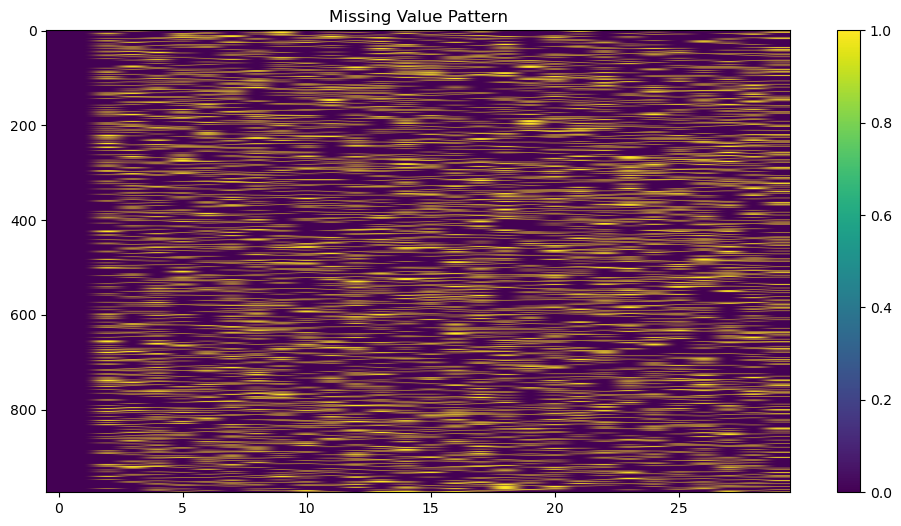

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.imshow(df.isnull(), aspect='auto')
plt.colorbar()
plt.title("Missing Value Pattern")
plt.show()

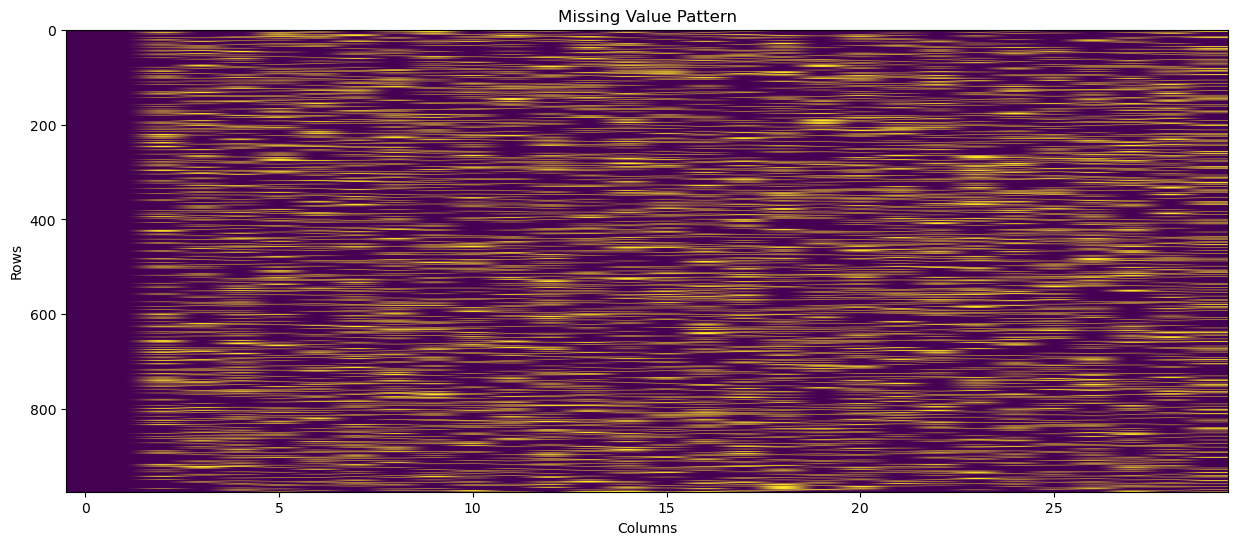

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.imshow(df.isnull(), aspect='auto')
plt.title("Missing Value Pattern")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

In [13]:
missing_rows = df.isnull().sum(axis=1)

print(missing_rows.describe())

count    975.000000
mean       5.600000
std        2.069134
min        0.000000
25%        4.000000
50%        5.000000
75%        7.000000
max       14.000000
dtype: float64


In [14]:
from scipy.interpolate import CubicSpline
from sklearn.metrics import mean_squared_error
import numpy as np

mse_list = []

surface_copy = surface.copy()

observed = np.argwhere(~surface_copy.isna().values)

rng = np.random.RandomState(42)

mask_idx = rng.choice(
    len(observed),
    size=int(0.1*len(observed)),
    replace=False
)

masked_positions = observed[mask_idx]

true_vals = []

for r,c in masked_positions:
    true_vals.append(surface_copy.iat[r,c])
    surface_copy.iat[r,c] = np.nan

preds = []

for r,c in masked_positions:

    row = surface_copy.iloc[r]

    valid = row.dropna()

    strikes = (
        valid.index
        .str.extract(r'(\d{5})')
        .astype(int)
        .values.flatten()
    )

    ivs = valid.values

    target_contract = surface_copy.columns[c]

    target_strike = int(
        ''.join(filter(str.isdigit,target_contract))[-5:]
    )

    if len(strikes) >= 4:

        try:

            spline = CubicSpline(
                strikes,
                ivs,
                extrapolate=True
            )

            pred = spline(target_strike)

        except:

            pred = np.mean(ivs)

    else:

        pred = np.mean(ivs)

    preds.append(pred)

mse = mean_squared_error(
    true_vals,
    preds
)

print("Spline MSE =", mse)

Spline MSE = 2900605134623860.0


In [15]:
row = surface.iloc[0]

valid = row.dropna()

print(valid.index.tolist())

['NIFTY27JAN2623800PE', 'NIFTY27JAN2623900PE', 'NIFTY27JAN2624000PE', 'NIFTY27JAN2624200PE', 'NIFTY27JAN2624300PE', 'NIFTY27JAN2624400PE', 'NIFTY27JAN2624500PE', 'NIFTY27JAN2624600PE', 'NIFTY27JAN2624700PE', 'NIFTY27JAN2624800PE', 'NIFTY27JAN2624900PE', 'NIFTY27JAN2625000PE', 'NIFTY27JAN2625100PE', 'NIFTY27JAN2625200CE', 'NIFTY27JAN2625300CE', 'NIFTY27JAN2625400CE', 'NIFTY27JAN2625600CE', 'NIFTY27JAN2625700CE', 'NIFTY27JAN2625900CE', 'NIFTY27JAN2626000CE', 'NIFTY27JAN2626100CE', 'NIFTY27JAN2626200CE', 'NIFTY27JAN2626300CE', 'NIFTY27JAN2626400CE', 'NIFTY27JAN2626500CE']


In [16]:
strikes = (
    valid.index
    .str.extract(r'(\d{5})')
    .astype(int)
)

print(strikes.head(10))

       0
0  26238
1  26239
2  26240
3  26242
4  26243
5  26244
6  26245
7  26246
8  26247
9  26248


In [17]:
def get_strike(contract):
    digits = ''.join(filter(str.isdigit, contract))
    return int(digits[-5:])

strikes = np.array(
    [get_strike(c) for c in valid.index]
)

In [19]:
print("len strikes =", len(strikes))
print("len ivs =", len(ivs))

len strikes = 25
len ivs = 17


In [20]:
row = surface.iloc[0]

valid = row.dropna()

contracts = valid.index.tolist()
ivs = valid.values

print("contracts =", len(contracts))
print("ivs =", len(ivs))

contracts = 25
ivs = 25


In [21]:
def get_strike(contract):
    return int(contract[-7:-2])

strikes = np.array(
    [get_strike(c) for c in contracts]
)

print("strikes =", len(strikes))
print(strikes[:10])

strikes = 25
[23800 23900 24000 24200 24300 24400 24500 24600 24700 24800]


In [22]:
print(len(strikes))
print(len(ivs))

25
25


In [23]:
order = np.argsort(strikes)

strikes_sorted = strikes[order]
ivs_sorted = ivs[order]

print(strikes_sorted[:10])
print(ivs_sorted[:10])

[23800 23900 24000 24200 24300 24400 24500 24600 24700 24800]
[0.1784  0.17237 0.16928 0.1576  0.1524  0.14697 0.14105 0.13613 0.13085
 0.1264 ]


In [24]:
print(len(strikes))
print(len(ivs))
print(strikes[:10])

25
25
[23800 23900 24000 24200 24300 24400 24500 24600 24700 24800]


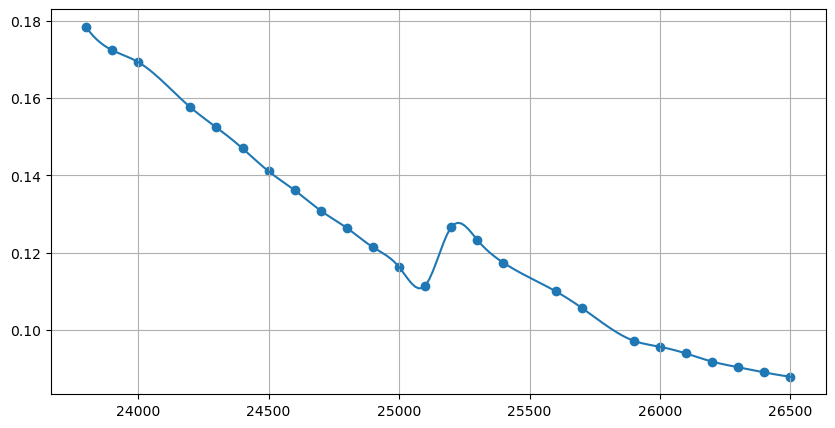

In [25]:
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

order = np.argsort(strikes)

strikes_sorted = strikes[order]
ivs_sorted = ivs[order]

spline = CubicSpline(
    strikes_sorted,
    ivs_sorted
)

x_new = np.linspace(
    strikes_sorted.min(),
    strikes_sorted.max(),
    200
)

y_new = spline(x_new)

plt.figure(figsize=(10,5))
plt.scatter(strikes_sorted, ivs_sorted)
plt.plot(x_new, y_new)
plt.grid()
plt.show()

In [26]:
from scipy.interpolate import PchipInterpolator

spline = PchipInterpolator(
    strikes_sorted,
    ivs_sorted
)

In [27]:
from scipy.interpolate import PchipInterpolator
from sklearn.metrics import mean_squared_error
import numpy as np

surface_copy = surface.copy()

observed = np.argwhere(~surface_copy.isna().values)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

true_vals = []
preds = []

for r,c in positions:

    true_iv = surface_copy.iat[r,c]

    row = surface_copy.iloc[r]

    valid = row.dropna()

    contracts = valid.index.tolist()

    strikes = np.array([
        int(x[-7:-2])
        for x in contracts
    ])

    ivs = valid.values

    target_contract = surface_copy.columns[c]
    target_strike = int(target_contract[-7:-2])

    if len(strikes) < 5:
        continue

    order = np.argsort(strikes)

    strikes = strikes[order]
    ivs = ivs[order]

    try:

        interp = PchipInterpolator(
            strikes,
            ivs,
            extrapolate=True
        )

        pred = interp(target_strike)

        preds.append(pred)
        true_vals.append(true_iv)

    except:
        pass

mse = mean_squared_error(
    true_vals,
    preds
)

print("PCHIP MSE =", mse)

PCHIP MSE = 3.4666738998970244e-35


In [28]:
r, c = positions[0]

print("Target position:")
print(r, c)

print("Value after masking:")
print(surface_copy.iat[r, c])

Target position:
650 6
Value after masking:
0.15731


In [29]:
r, c = positions[0]
print(surface_copy.iat[r, c])

0.15731


In [30]:
surface_test = surface.copy()

In [31]:
import numpy as np

observed = np.argwhere(~surface_test.isna().values)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

In [32]:
from scipy.interpolate import PchipInterpolator
from sklearn.metrics import mean_squared_error
import numpy as np

true_vals = []
preds = []

for r, c in positions:

    true_iv = surface_test.iat[r, c]

    # Copy row
    row = surface_test.iloc[r].copy()

    # Remove target point
    row.iloc[c] = np.nan

    valid = row.dropna()

    if len(valid) < 5:
        continue

    strikes = np.array([
        int(contract[-7:-2])
        for contract in valid.index
    ])

    ivs = valid.values

    order = np.argsort(strikes)

    strikes = strikes[order]
    ivs = ivs[order]

    target_contract = surface_test.columns[c]
    target_strike = int(target_contract[-7:-2])

    try:

        interp = PchipInterpolator(
            strikes,
            ivs,
            extrapolate=True
        )

        pred = interp(target_strike)

        preds.append(pred)
        true_vals.append(true_iv)

    except:
        pass

mse = mean_squared_error(
    true_vals,
    preds
)

print("Correct PCHIP MSE =", mse)

Correct PCHIP MSE = 0.00030329564444797857


In [33]:
surface = long_df.pivot_table(
    index='datetime',
    columns='contract',
    values='iv'
)

In [34]:
contract_info = []

for c in surface.columns:
    strike = int(c[-7:-2])
    contract_info.append((c, strike))

contract_info = sorted(contract_info, key=lambda x: x[1])

sorted_contracts = [x[0] for x in contract_info]

surface = surface[sorted_contracts]

In [35]:
print(surface.columns[:10])

Index(['NIFTY27JAN2623800PE', 'NIFTY27JAN2623900PE', 'NIFTY27JAN2624000PE',
       'NIFTY27JAN2624100PE', 'NIFTY27JAN2624200PE', 'NIFTY27JAN2624300PE',
       'NIFTY27JAN2624400PE', 'NIFTY27JAN2624500PE', 'NIFTY27JAN2624600PE',
       'NIFTY27JAN2624700PE'],
      dtype='object', name='contract')


In [36]:
neighbor_df = surface.copy()

neighbor_df['datetime'] = neighbor_df.index

In [37]:
long_neighbor = surface.stack(dropna=False).reset_index()

long_neighbor.columns = [
    'datetime',
    'contract',
    'iv'
]

C:\Users\B Mithun\AppData\Local\Temp\ipykernel_16244\2840396189.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_neighbor = surface.stack(dropna=False).reset_index()


In [38]:
long_neighbor['strike'] = (
    long_neighbor['contract']
    .str[-7:-2]
    .astype(int)
)

long_neighbor['option_type'] = (
    long_neighbor['contract']
    .str[-2:]
)

In [39]:
contract_order = {
    c:i for i,c in enumerate(surface.columns)
}

In [40]:
long_neighbor['position'] = (
    long_neighbor['contract']
    .map(contract_order)
)

In [41]:
surface_values = surface.values

left_iv = []
right_iv = []
left2_iv = []
right2_iv = []

for _, row in long_neighbor.iterrows():

    r = surface.index.get_loc(row['datetime'])
    c = row['position']

    # Left
    left_iv.append(
        surface_values[r, c-1]
        if c-1 >= 0 else np.nan
    )

    # Right
    right_iv.append(
        surface_values[r, c+1]
        if c+1 < surface.shape[1] else np.nan
    )

    # Left2
    left2_iv.append(
        surface_values[r, c-2]
        if c-2 >= 0 else np.nan
    )

    # Right2
    right2_iv.append(
        surface_values[r, c+2]
        if c+2 < surface.shape[1] else np.nan
    )

In [42]:
long_neighbor['left_iv'] = left_iv
long_neighbor['right_iv'] = right_iv
long_neighbor['left2_iv'] = left2_iv
long_neighbor['right2_iv'] = right2_iv

In [44]:
print(long_neighbor['datetime'].dtype)
print(df['datetime'].dtype)

datetime64[ns]
object


In [45]:
df['datetime'] = pd.to_datetime(
    df['datetime'],
    format='%d-%m-%Y %H:%M'
)

In [46]:
long_neighbor = long_neighbor.merge(
    df[['datetime','underlying_price']],
    on='datetime',
    how='left'
)

In [47]:
print(long_neighbor[['datetime','underlying_price']].head())

             datetime  underlying_price
0 2026-01-07 09:15:00          26111.65
1 2026-01-07 09:15:00          26111.65
2 2026-01-07 09:15:00          26111.65
3 2026-01-07 09:15:00          26111.65
4 2026-01-07 09:15:00          26111.65


In [48]:
print(
    long_neighbor[
        ['contract',
         'left_iv',
         'right_iv',
         'left2_iv',
         'right2_iv']
    ].head(10)
)

              contract  left_iv  right_iv  left2_iv  right2_iv
0  NIFTY27JAN2623800PE      NaN   0.17237       NaN    0.16928
1  NIFTY27JAN2623900PE  0.17840   0.16928       NaN        NaN
2  NIFTY27JAN2624000PE  0.17237       NaN   0.17840    0.15760
3  NIFTY27JAN2624100PE  0.16928   0.15760   0.17237    0.15240
4  NIFTY27JAN2624200PE      NaN   0.15240   0.16928    0.14697
5  NIFTY27JAN2624300PE  0.15760   0.14697       NaN    0.14105
6  NIFTY27JAN2624400PE  0.15240   0.14105   0.15760    0.13613
7  NIFTY27JAN2624500PE  0.14697   0.13613   0.15240    0.13085
8  NIFTY27JAN2624600PE  0.14105   0.13085   0.14697    0.12640
9  NIFTY27JAN2624700PE  0.13613   0.12640   0.14105    0.12142


In [49]:
train_df = long_neighbor[
    long_neighbor['iv'].notnull()
].copy()

pred_df = long_neighbor[
    long_neighbor['iv'].isnull()
].copy()

In [50]:
print("Neighbor Feature MSE =", mse)

Neighbor Feature MSE = 0.00030329564444797857


In [53]:
print(df.shape)
print(df.columns[:10])

(975, 30)
Index(['datetime', 'underlying_price', 'NIFTY27JAN2625200CE',
       'NIFTY27JAN2625300CE', 'NIFTY27JAN2625400CE', 'NIFTY27JAN2625500CE',
       'NIFTY27JAN2625600CE', 'NIFTY27JAN2625700CE', 'NIFTY27JAN2625800CE',
       'NIFTY27JAN2625900CE'],
      dtype='object')


In [54]:
surface = df.copy()

In [55]:
print(df.head())

             datetime  underlying_price  NIFTY27JAN2625200CE  \
0 2026-01-07 09:15:00          26111.65              0.12662   
1 2026-01-07 09:20:00          26141.40              0.08632   
2 2026-01-07 09:25:00          26139.35              0.09147   
3 2026-01-07 09:30:00          26128.95              0.10860   
4 2026-01-07 09:35:00          26131.90              0.10462   

   NIFTY27JAN2625300CE  NIFTY27JAN2625400CE  NIFTY27JAN2625500CE  \
0              0.12330              0.11741                  NaN   
1                  NaN                  NaN              0.11779   
2                  NaN              0.09514              0.09933   
3              0.10842              0.11150              0.12248   
4              0.10538              0.12459              0.12051   

   NIFTY27JAN2625600CE  NIFTY27JAN2625700CE  NIFTY27JAN2625800CE  \
0              0.11005              0.10576                  NaN   
1              0.11197              0.11028                  NaN   
2 

In [56]:
surface = df.drop(
    columns=['datetime', 'underlying_price']
)

print(surface.shape)

(975, 28)


In [57]:
print(surface.isnull().sum().sum())

5460


In [58]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface.copy()

observed = np.argwhere(~surface_test.isna().values)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r, c in positions:
    true_vals.append(surface_test.iat[r, c])
    surface_test.iat[r, c] = np.nan

imp = IterativeImputer(
    max_iter=20,
    random_state=42
)

filled = imp.fit_transform(surface_test)

preds = []

for r, c in positions:
    preds.append(filled[r, c])

mse = mean_squared_error(
    true_vals,
    preds
)

print("Iterative Imputer MSE =", mse)

Iterative Imputer MSE = 0.00010441112743197219


In [59]:
from sklearn.decomposition import TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface.copy()

observed = np.argwhere(~surface_test.isna().values)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r,c in positions:
    true_vals.append(surface_test.iat[r,c])
    surface_test.iat[r,c] = np.nan

# initial fill
filled0 = surface_test.fillna(
    surface_test.mean()
)

for k in [3,5,7,10]:
    
    svd = TruncatedSVD(
        n_components=k,
        random_state=42
    )

    X_low = svd.fit_transform(filled0)
    X_recon = svd.inverse_transform(X_low)

    preds = []

    for r,c in positions:
        preds.append(X_recon[r,c])

    mse = mean_squared_error(
        true_vals,
        preds
    )

    print(
        f'k={k}  MSE={mse}'
    )

k=3  MSE=0.013075839004804796
k=5  MSE=0.02036203311187332
k=7  MSE=0.025637757415525476
k=10  MSE=0.030662004196501703


In [60]:
surface_plus = df.drop(columns=['datetime']).copy()

print(surface_plus.shape)
print(surface_plus.isnull().sum().sum())

(975, 29)
5460


In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface_plus.copy()

# Only IV columns can be masked
iv_cols = surface_test.columns[1:]

observed = []

for col_idx, col in enumerate(iv_cols, start=1):

    rows = np.where(
        ~surface_test[col].isna()
    )[0]

    for r in rows:
        observed.append((r, col_idx))

observed = np.array(observed)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r, c in positions:

    true_vals.append(
        surface_test.iat[r, c]
    )

    surface_test.iat[r, c] = np.nan

In [62]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(
    max_iter=100,
    tol=1e-8,
    random_state=42
)

filled = imp.fit_transform(
    surface_test
)

In [63]:
preds = []

for r, c in positions:

    preds.append(
        filled[r, c]
    )

mse = mean_squared_error(
    true_vals,
    preds
)

print(
    "Iterative + Underlying MSE =",
    mse
)

Iterative + Underlying MSE = 0.00010526269090247507


In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

rf_imp = IterativeImputer(
    estimator=RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=20,
    random_state=42
)

filled_rf = rf_imp.fit_transform(
    surface_test
)

In [65]:
preds_rf = []

for r, c in positions:

    preds_rf.append(
        filled_rf[r, c]
    )

rf_mse = mean_squared_error(
    true_vals,
    preds_rf
)

print(
    "RF Iterative MSE =",
    rf_mse
)

RF Iterative MSE = 0.0032471518561410524


In [66]:
ensemble_preds = (
    np.array(preds) +
    np.array(preds_rf)
) / 2

ensemble_mse = mean_squared_error(
    true_vals,
    ensemble_preds
)

print(
    "Ensemble MSE =",
    ensemble_mse
)

Ensemble MSE = 0.0008557454907295307


In [3]:
import pandas as pd

df = pd.read_csv("dataset.csv")

print(df.shape)
print(df.head())

(975, 30)
           datetime  underlying_price  NIFTY27JAN2625200CE  \
0  07-01-2026 09:15          26111.65              0.12662   
1  07-01-2026 09:20          26141.40              0.08632   
2  07-01-2026 09:25          26139.35              0.09147   
3  07-01-2026 09:30          26128.95              0.10860   
4  07-01-2026 09:35          26131.90              0.10462   

   NIFTY27JAN2625300CE  NIFTY27JAN2625400CE  NIFTY27JAN2625500CE  \
0              0.12330              0.11741                  NaN   
1                  NaN                  NaN              0.11779   
2                  NaN              0.09514              0.09933   
3              0.10842              0.11150              0.12248   
4              0.10538              0.12459              0.12051   

   NIFTY27JAN2625600CE  NIFTY27JAN2625700CE  NIFTY27JAN2625800CE  \
0              0.11005              0.10576                  NaN   
1              0.11197              0.11028                  NaN   
2   

In [4]:
print(df.columns.tolist())

['datetime', 'underlying_price', 'NIFTY27JAN2625200CE', 'NIFTY27JAN2625300CE', 'NIFTY27JAN2625400CE', 'NIFTY27JAN2625500CE', 'NIFTY27JAN2625600CE', 'NIFTY27JAN2625700CE', 'NIFTY27JAN2625800CE', 'NIFTY27JAN2625900CE', 'NIFTY27JAN2626000CE', 'NIFTY27JAN2626100CE', 'NIFTY27JAN2626200CE', 'NIFTY27JAN2626300CE', 'NIFTY27JAN2626400CE', 'NIFTY27JAN2626500CE', 'NIFTY27JAN2623800PE', 'NIFTY27JAN2623900PE', 'NIFTY27JAN2624000PE', 'NIFTY27JAN2624100PE', 'NIFTY27JAN2624200PE', 'NIFTY27JAN2624300PE', 'NIFTY27JAN2624400PE', 'NIFTY27JAN2624500PE', 'NIFTY27JAN2624600PE', 'NIFTY27JAN2624700PE', 'NIFTY27JAN2624800PE', 'NIFTY27JAN2624900PE', 'NIFTY27JAN2625000PE', 'NIFTY27JAN2625100PE']


In [5]:
import pandas as pd

df = pd.read_csv("dataset.csv")
print(df.shape)
print(df.columns.tolist()[:10])

(975, 30)
['datetime', 'underlying_price', 'NIFTY27JAN2625200CE', 'NIFTY27JAN2625300CE', 'NIFTY27JAN2625400CE', 'NIFTY27JAN2625500CE', 'NIFTY27JAN2625600CE', 'NIFTY27JAN2625700CE', 'NIFTY27JAN2625800CE', 'NIFTY27JAN2625900CE']


In [6]:
surface = df.drop(
    columns=[
        'datetime',
        'underlying_price'
    ]
)

print(surface.shape)
print(surface.isnull().sum().sum())

(975, 28)
5460


In [7]:
!pip install fancyimpute

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/13.6 MB ? eta -:--:--
   --- ------------------------------------ 1.0/13.6 MB 6.9 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/13.6 MB 6.9 MB/s eta 0:00:02
   --- ------------------------------------ 1.0/13.6 MB 6.9 MB/s eta 0:00:02
   --- --------------------------------

In [8]:
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface.copy()

observed = np.argwhere(
    ~surface_test.isna().values
)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r,c in positions:
    true_vals.append(
        surface_test.iat[r,c]
    )
    surface_test.iat[r,c] = np.nan

In [9]:
from fancyimpute import SoftImpute

filled = SoftImpute(
    max_iters=200
).fit_transform(
    surface_test.values
)

[SoftImpute] Max Singular Value of X_init = 33.678699
[SoftImpute] Iter 1: observed MAE=0.012912 rank=28
[SoftImpute] Iter 2: observed MAE=0.012926 rank=28
[SoftImpute] Iter 3: observed MAE=0.012924 rank=28
[SoftImpute] Iter 4: observed MAE=0.012906 rank=28
[SoftImpute] Iter 5: observed MAE=0.012724 rank=26
[SoftImpute] Iter 6: observed MAE=0.011769 rank=20
[SoftImpute] Iter 7: observed MAE=0.010756 rank=17
[SoftImpute] Iter 8: observed MAE=0.009926 rank=15
[SoftImpute] Iter 9: observed MAE=0.009552 rank=15
[SoftImpute] Iter 10: observed MAE=0.009368 rank=14
[SoftImpute] Iter 11: observed MAE=0.009202 rank=13
[SoftImpute] Iter 12: observed MAE=0.008962 rank=11
[SoftImpute] Iter 13: observed MAE=0.008753 rank=10
[SoftImpute] Iter 14: observed MAE=0.008550 rank=9
[SoftImpute] Iter 15: observed MAE=0.008363 rank=8
[SoftImpute] Iter 16: observed MAE=0.008203 rank=8
[SoftImpute] Iter 17: observed MAE=0.008107 rank=7
[SoftImpute] Iter 18: observed MAE=0.008021 rank=7
[SoftImpute] Iter 19: ob

C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [10]:
preds = []

for r,c in positions:
    preds.append(
        filled[r,c]
    )

mse = mean_squared_error(
    true_vals,
    preds
)

print(
    "SoftImpute MSE =",
    mse
)

SoftImpute MSE = 0.00022411577933812563


In [11]:
for lam in [0.001,0.01,0.05,0.1]:

    filled = SoftImpute(
        shrinkage_value=lam,
        max_iters=200
    ).fit_transform(
        surface_test.values
    )

    preds = [
        filled[r,c]
        for r,c in positions
    ]

    mse = mean_squared_error(
        true_vals,
        preds
    )

    print(
        lam,
        mse
    )

C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 33.678699
[SoftImpute] Iter 1: observed MAE=0.000019 rank=28
[SoftImpute] Iter 2: observed MAE=0.000019 rank=28
[SoftImpute] Iter 3: observed MAE=0.000019 rank=28
[SoftImpute] Iter 4: observed MAE=0.000019 rank=28
[SoftImpute] Iter 5: observed MAE=0.000019 rank=28
[SoftImpute] Iter 6: observed MAE=0.000019 rank=28
[SoftImpute] Iter 7: observed MAE=0.000019 rank=28
[SoftImpute] Iter 8: observed MAE=0.000019 rank=28
[SoftImpute] Iter 9: observed MAE=0.000019 rank=28
[SoftImpute] Iter 10: observed MAE=0.000019 rank=28
[SoftImpute] Iter 11: observed MAE=0.000019 rank=28
[SoftImpute] Iter 12: observed MAE=0.000019 rank=28
[SoftImpute] Iter 13: observed MAE=0.000019 rank=28
[SoftImpute] Iter 14: observed MAE=0.000019 rank=28
[SoftImpute] Iter 15: observed MAE=0.000019 rank=28
[SoftImpute] Iter 16: observed MAE=0.000019 rank=28
[SoftImpute] Iter 17: observed MAE=0.000019 rank=28
[SoftImpute] Iter 18: observed MAE=0.000019 rank=28
[SoftImpute] Iter 1

C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Iter 19: observed MAE=0.000192 rank=28
[SoftImpute] Iter 20: observed MAE=0.000192 rank=28
[SoftImpute] Iter 21: observed MAE=0.000192 rank=28
[SoftImpute] Iter 22: observed MAE=0.000192 rank=28
[SoftImpute] Iter 23: observed MAE=0.000192 rank=28
[SoftImpute] Iter 24: observed MAE=0.000192 rank=28
[SoftImpute] Iter 25: observed MAE=0.000192 rank=28
[SoftImpute] Iter 26: observed MAE=0.000192 rank=28
[SoftImpute] Iter 27: observed MAE=0.000192 rank=28
[SoftImpute] Iter 28: observed MAE=0.000192 rank=28
[SoftImpute] Iter 29: observed MAE=0.000192 rank=28
[SoftImpute] Iter 30: observed MAE=0.000192 rank=28
[SoftImpute] Iter 31: observed MAE=0.000192 rank=28
[SoftImpute] Iter 32: observed MAE=0.000192 rank=28
[SoftImpute] Iter 33: observed MAE=0.000192 rank=28
[SoftImpute] Iter 34: observed MAE=0.000192 rank=28
[SoftImpute] Iter 35: observed MAE=0.000192 rank=28
[SoftImpute] Iter 36: observed MAE=0.000192 rank=28
[SoftImpute] Iter 37: observed MAE=0.000192 rank=28
[SoftImpute]

C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Iter 73: observed MAE=0.000950 rank=28
[SoftImpute] Iter 74: observed MAE=0.000949 rank=28
[SoftImpute] Iter 75: observed MAE=0.000949 rank=28
[SoftImpute] Iter 76: observed MAE=0.000949 rank=28
[SoftImpute] Iter 77: observed MAE=0.000948 rank=28
[SoftImpute] Iter 78: observed MAE=0.000948 rank=28
[SoftImpute] Iter 79: observed MAE=0.000947 rank=28
[SoftImpute] Iter 80: observed MAE=0.000947 rank=28
[SoftImpute] Iter 81: observed MAE=0.000946 rank=28
[SoftImpute] Iter 82: observed MAE=0.000946 rank=28
[SoftImpute] Iter 83: observed MAE=0.000945 rank=28
[SoftImpute] Iter 84: observed MAE=0.000945 rank=28
[SoftImpute] Iter 85: observed MAE=0.000944 rank=28
[SoftImpute] Iter 86: observed MAE=0.000944 rank=28
[SoftImpute] Iter 87: observed MAE=0.000943 rank=28
[SoftImpute] Iter 88: observed MAE=0.000943 rank=28
[SoftImpute] Iter 89: observed MAE=0.000943 rank=28
[SoftImpute] Iter 90: observed MAE=0.000942 rank=28
[SoftImpute] Iter 91: observed MAE=0.000942 rank=28
[SoftImpute]

C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\B Mithun\anaconda3\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Iter 52: observed MAE=0.001839 rank=25
[SoftImpute] Iter 53: observed MAE=0.001830 rank=25
[SoftImpute] Iter 54: observed MAE=0.001824 rank=25
[SoftImpute] Iter 55: observed MAE=0.001816 rank=24
[SoftImpute] Iter 56: observed MAE=0.001808 rank=23
[SoftImpute] Iter 57: observed MAE=0.001795 rank=23
[SoftImpute] Iter 58: observed MAE=0.001782 rank=22
[SoftImpute] Iter 59: observed MAE=0.001774 rank=22
[SoftImpute] Iter 60: observed MAE=0.001765 rank=21
[SoftImpute] Iter 61: observed MAE=0.001760 rank=20
[SoftImpute] Iter 62: observed MAE=0.001749 rank=20
[SoftImpute] Iter 63: observed MAE=0.001742 rank=20
[SoftImpute] Iter 64: observed MAE=0.001735 rank=19
[SoftImpute] Iter 65: observed MAE=0.001729 rank=19
[SoftImpute] Iter 66: observed MAE=0.001724 rank=19
[SoftImpute] Iter 67: observed MAE=0.001721 rank=19
[SoftImpute] Iter 68: observed MAE=0.001719 rank=19
[SoftImpute] Iter 69: observed MAE=0.001717 rank=19
[SoftImpute] Iter 70: observed MAE=0.001716 rank=19
[SoftImpute]

In [12]:
missing_per_col = surface.isna().sum()

print(
    missing_per_col.sort_values(
        ascending=False
    )
)

NIFTY27JAN2624200PE    217
NIFTY27JAN2626400CE    213
NIFTY27JAN2625800CE    210
NIFTY27JAN2626200CE    209
NIFTY27JAN2624800PE    209
NIFTY27JAN2624000PE    209
NIFTY27JAN2625100PE    205
NIFTY27JAN2623800PE    203
NIFTY27JAN2625400CE    202
NIFTY27JAN2624400PE    202
NIFTY27JAN2625700CE    201
NIFTY27JAN2623900PE    201
NIFTY27JAN2624600PE    198
NIFTY27JAN2625000PE    195
NIFTY27JAN2624900PE    195
NIFTY27JAN2624500PE    195
NIFTY27JAN2625200CE    194
NIFTY27JAN2624300PE    189
NIFTY27JAN2626300CE    187
NIFTY27JAN2626500CE    184
NIFTY27JAN2625300CE    184
NIFTY27JAN2626100CE    183
NIFTY27JAN2625900CE    182
NIFTY27JAN2626000CE    181
NIFTY27JAN2625500CE    181
NIFTY27JAN2625600CE    180
NIFTY27JAN2624100PE    176
NIFTY27JAN2624700PE    175
dtype: int64


In [13]:
import pandas as pd

df = pd.read_csv("dataset.csv")

surface = df.drop(
    columns=[
        'datetime',
        'underlying_price'
    ]
)

print(surface.shape)
print(surface.isna().sum().sum())

(975, 28)
5460


In [14]:
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface.copy()

observed = np.argwhere(
    ~surface_test.isna().values
)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=2000,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r, c in positions:

    true_vals.append(
        surface_test.iat[r, c]
    )

    surface_test.iat[r, c] = np.nan

In [15]:
surface_init = surface_test.interpolate(
    method='linear',
    axis=0,
    limit_direction='both'
)

print(
    surface_init.isna().sum().sum()
)

0


In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imp = IterativeImputer(
    max_iter=50,
    random_state=42,
    tol=1e-6
)

filled = imp.fit_transform(
    surface_init
)

In [17]:
preds = []

for r, c in positions:

    preds.append(
        filled[r, c]
    )

mse = mean_squared_error(
    true_vals,
    preds
)

print(
    "Time+Iterative MSE =",
    mse
)

Time+Iterative MSE = 0.00028314462551839347


In [19]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.impute import IterativeImputer
from sklearn.experimental import enable_iterative_imputer

In [20]:
imp = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=1000,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=50,
    random_state=42
)

In [21]:
import pandas as pd
import numpy as np

df = pd.read_csv("dataset.csv")

option_cols = [
    c for c in df.columns
    if c not in ['datetime', 'underlying_price']
]

print(len(option_cols))

28


In [22]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

mse_list = []

rng = np.random.RandomState(42)

for target_col in option_cols:

    temp = df.copy()

    known_rows = temp[
        temp[target_col].notna()
    ].copy()

    # Validation split
    idx = rng.choice(
        known_rows.index,
        size=min(150, len(known_rows)//5),
        replace=False
    )

    valid = known_rows.loc[idx]
    train = known_rows.drop(idx)

    features = [
        c for c in option_cols
        if c != target_col
    ]

    features.append(
        'underlying_price'
    )

    X_train = train[features]
    y_train = train[target_col]

    X_valid = valid[features]
    y_valid = valid[target_col]

    # Fill remaining NaNs in features
    X_train = X_train.fillna(
        X_train.median()
    )

    X_valid = X_valid.fillna(
        X_train.median()
    )

    model = XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_valid
    )

    mse = mean_squared_error(
        y_valid,
        pred
    )

    mse_list.append(mse)

    print(
        target_col,
        mse
    )

NIFTY27JAN2625200CE 0.00048548992460103064
NIFTY27JAN2625300CE 0.00016562622501344122
NIFTY27JAN2625400CE 0.0002460814152459138
NIFTY27JAN2625500CE 0.0034365918706279587
NIFTY27JAN2625600CE 9.147422790717969e-05
NIFTY27JAN2625700CE 0.0002247666645697725
NIFTY27JAN2625800CE 0.004376726882527782
NIFTY27JAN2625900CE 0.004094433721176475
NIFTY27JAN2626000CE 0.001680575228831311
NIFTY27JAN2626100CE 0.0014675036558629384
NIFTY27JAN2626200CE 0.002822716558716084
NIFTY27JAN2626300CE 0.0031368031399405167
NIFTY27JAN2626400CE 0.014971700768244976
NIFTY27JAN2626500CE 0.0006484390292620859
NIFTY27JAN2623800PE 0.00410711712222912
NIFTY27JAN2623900PE 0.002202567300415655
NIFTY27JAN2624000PE 0.003215322437779882
NIFTY27JAN2624100PE 0.0012483629808250126
NIFTY27JAN2624200PE 0.00048113441665688464
NIFTY27JAN2624300PE 0.015611474797110562
NIFTY27JAN2624400PE 0.0015940967332894577
NIFTY27JAN2624500PE 0.0017951049068013626
NIFTY27JAN2624600PE 0.0005091381008621519
NIFTY27JAN2624700PE 0.007231070376813073


In [23]:
print(
    "Average MSE:",
    np.mean(mse_list)
)

Average MSE: 0.0027991410969313824


In [24]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface.copy()

observed = np.argwhere(
    ~surface_test.isna().values
)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=4500,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r,c in positions:
    true_vals.append(
        surface_test.iat[r,c]
    )
    surface_test.iat[r,c] = np.nan

imp = IterativeImputer(
    max_iter=50,
    random_state=42
)

filled = imp.fit_transform(
    surface_test
)

preds = [
    filled[r,c]
    for r,c in positions
]

mse = mean_squared_error(
    true_vals,
    preds
)

print(
    "Competition-like MSE =",
    mse
)

Competition-like MSE = 0.00026836579922375354


In [25]:
missing_rows = surface.isna().sum(axis=1)

print(missing_rows.describe())
print(missing_rows.value_counts().sort_index())

count    975.000000
mean       5.600000
std        2.069134
min        0.000000
25%        4.000000
50%        5.000000
75%        7.000000
max       14.000000
dtype: float64
0       3
1      10
2      31
3     100
4     162
5     186
6     187
7     127
8      84
9      49
10     19
11     10
12      6
14      1
Name: count, dtype: int64


In [1]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
%who

IterativeImputer	 enable_iterative_imputer	 mean_squared_error	 np	 


In [3]:
import pandas as pd

df = pd.read_csv("dataset.csv")
print(df.shape)
print(df.head())

(975, 30)
           datetime  underlying_price  NIFTY27JAN2625200CE  \
0  07-01-2026 09:15          26111.65              0.12662   
1  07-01-2026 09:20          26141.40              0.08632   
2  07-01-2026 09:25          26139.35              0.09147   
3  07-01-2026 09:30          26128.95              0.10860   
4  07-01-2026 09:35          26131.90              0.10462   

   NIFTY27JAN2625300CE  NIFTY27JAN2625400CE  NIFTY27JAN2625500CE  \
0              0.12330              0.11741                  NaN   
1                  NaN                  NaN              0.11779   
2                  NaN              0.09514              0.09933   
3              0.10842              0.11150              0.12248   
4              0.10538              0.12459              0.12051   

   NIFTY27JAN2625600CE  NIFTY27JAN2625700CE  NIFTY27JAN2625800CE  \
0              0.11005              0.10576                  NaN   
1              0.11197              0.11028                  NaN   
2   

In [4]:
%who

IterativeImputer	 df	 enable_iterative_imputer	 mean_squared_error	 np	 pd	 


In [5]:
surface = df.drop(
    columns=["datetime", "underlying_price"]
)

In [6]:
print(surface.shape)
print(surface.isna().sum().sum())

(975, 28)
5460


In [7]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
import numpy as np

surface_test = surface.copy()

observed = np.argwhere(
    ~surface_test.isna().values
)

rng = np.random.RandomState(42)

sample_idx = rng.choice(
    len(observed),
    size=4500,
    replace=False
)

positions = observed[sample_idx]

true_vals = []

for r, c in positions:
    true_vals.append(surface_test.iat[r, c])
    surface_test.iat[r, c] = np.nan

configs = [20, 50, 100]

results = {}

for iters in configs:

    imp = IterativeImputer(
        max_iter=iters,
        random_state=42
    )

    filled = imp.fit_transform(surface_test)

    preds = [
        filled[r, c]
        for r, c in positions
    ]

    mse = mean_squared_error(
        true_vals,
        preds
    )

    results[iters] = mse

print(results)

{20: 0.00026836579922375354, 50: 0.00026836579922375354, 100: 0.00026836579922375354}


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_squared_error

imp = IterativeImputer(
    estimator=ExtraTreesRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    max_iter=20,
    random_state=42
)

filled = imp.fit_transform(surface_test)

preds = [
    filled[r, c]
    for r, c in positions
]

mse = mean_squared_error(
    true_vals,
    preds
)

print("ExtraTrees MSE =", mse)

In [ ]:
missing_per_row = surface.isna().sum(axis=1)

print(missing_per_row.describe())

print(
    missing_per_row
    .value_counts()
    .sort_index()
)